# Projekt: Choroby skóry - Zbiór Fitzpatrick17k
**Autor:** Wiktor Grzyb  
**Cel:** Analiza i klasyfikacja chorób skóry na podstawie obrazów z uwzględnieniem fototypu skóry.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pakiety do uczenia maszynowego
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

# Konfiguracja wizualna wykresów
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Ścieżki do plików
DATA_DIR = "data/fitzpatrick17k"
CSV_PATH = os.path.join(DATA_DIR, "fitzpatrick17k.csv")
IMG_DIR = os.path.join(DATA_DIR, "images")

# Wykrywanie dostępności karty graficznej (na Twoim sprzęcie wybierze CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Używane urządzenie obliczeniowe: {device}")

Używane urządzenie obliczeniowe: cpu


## 1. Wczytanie metadanych i synchronizacja ze zdjęciami
Ładujemy plik CSV i sprawdzamy fizyczną obecność plików.

In [3]:
df = pd.read_csv(CSV_PATH)
print(f"Początkowa liczba wierszy (z CSV): {len(df)}")

if os.path.exists(IMG_DIR):
    istniejace_zdjecia = set(os.listdir(IMG_DIR))
else:
    istniejace_zdjecia = set()

df['image_exists'] = df['md5hash'].apply(lambda x: f"{x}.jpg" in istniejace_zdjecia)
df_filtered = df[df['image_exists']].copy()

print(f"Liczba wierszy z dostępnymi zdjęciami: {len(df_filtered)}")

if len(df_filtered) == 0:
    raise ValueError("BŁĄD: Nie znaleziono zdjęć! Pobierz archiwum ZIP z Kaggle i wypakuj do data/fitzpatrick17k/images/")

Początkowa liczba wierszy (z CSV): 16577
Liczba wierszy z dostępnymi zdjęciami: 16574


## 2. Redukcja zbioru danych (Opcja wydajnościowa dla CPU)
Losujemy 10% całego zbioru, aby umożliwić szybkie trenowanie modelu na procesorze w celach weryfikacji pipeline'u.

Zredukowano zbiór do 10.0% dla szybszych obliczeń CPU.
Nowa liczba wierszy do treningu: 1657


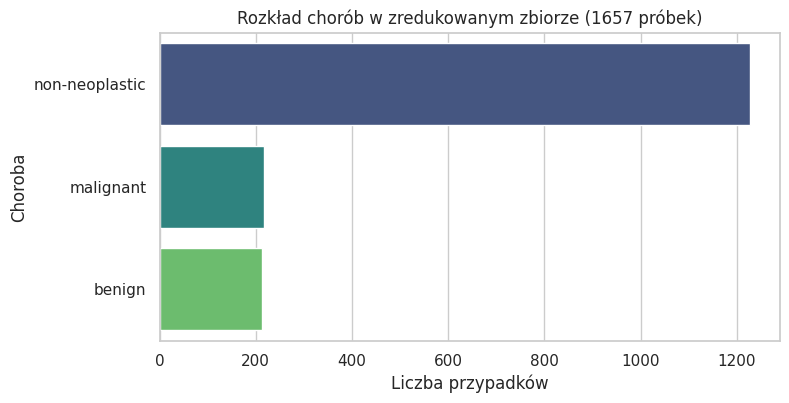

In [4]:
FRACTION = 0.10  # 10% danych
target_col = 'three_partition_label' if 'three_partition_label' in df_filtered.columns else 'label'

# Mapowanie etykiet (string -> int) na całym zbiorze, żeby nie zgubić jakiejś rzadkiej klasy
labels = df_filtered[target_col].unique()
label_to_idx = {label: idx for idx, label in enumerate(labels)}
df_filtered['target'] = df_filtered[target_col].map(label_to_idx)

# Losowanie 10% próbek (random_state=42 zapewnia reprodukowalność u innych członków zespołu)
df_subset = df_filtered.sample(frac=FRACTION, random_state=42).reset_index(drop=True)

print(f"Zredukowano zbiór do {FRACTION*100}% dla szybszych obliczeń CPU.")
print(f"Nowa liczba wierszy do treningu: {len(df_subset)}")

# Wykres rozkładu na zmniejszonym zbiorze
plt.figure(figsize=(8, 4))
sns.countplot(data=df_subset, y=target_col, hue=target_col, palette="viridis", legend=False)
plt.title(f"Rozkład chorób w zredukowanym zbiorze ({len(df_subset)} próbek)")
plt.xlabel("Liczba przypadków")
plt.ylabel("Choroba")
plt.show()

## 3. Przygotowanie Datasetu (PyTorch)
Definiujemy transformacje obrazów (resize do 224×224, normalizacja ImageNet, augmentacja) oraz klasę `FitzpatrickDataset`.

In [5]:
# Transformacje (Resize do 224x224 to standard dla ResNet)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class FitzpatrickDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = f"{self.dataframe.loc[idx, 'md5hash']}.jpg"
        img_path = os.path.join(self.img_dir, img_name)

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        label = self.dataframe.loc[idx, 'target']
        return image, torch.tensor(label, dtype=torch.long)

## 4. Pełna Walidacja Krzyżowa (5-Fold CV) i Trening
Zgodnie z wymaganiami projektu, przeprowadzamy 5-krotną walidację krzyżową,  
trenując model ResNet-18 (Transfer Learning) na każdym z podziałów.

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

# Upewnienie się, że folder na wyniki istnieje
os.makedirs("../results", exist_ok=True)

print("Rozpoczynamy 5-krotną walidację krzyżową (1 epoka na fold dla optymalizacji CPU)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(df_subset, df_subset['target'])):
    print(f"\n{'='*40}")
    print(f"FOLD {fold+1}/5")
    print(f"{'='*40}")

    # 1. Przygotowanie danych dla danego foldu
    train_df = df_subset.iloc[train_idx]
    val_df = df_subset.iloc[val_idx]

    train_dataset = FitzpatrickDataset(train_df, IMG_DIR, transform=transform)
    val_dataset = FitzpatrickDataset(val_df, IMG_DIR, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    # 2. Inicjalizacja czystego modelu dla każdego foldu
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False

    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(labels))
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

    # 3. Trening (1 epoka)
    model.train()
    for inputs, labels_batch in tqdm(train_loader, desc=f"Trening Fold {fold+1}"):
        inputs, labels_batch = inputs.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

    # 4. Walidacja
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for inputs, labels_batch in tqdm(val_loader, desc=f"Walidacja Fold {fold+1}"):
            inputs, labels_batch = inputs.to(device), labels_batch.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(labels_batch.cpu().numpy())

    # 5. Obliczenie metryk
    acc = accuracy_score(all_true, all_preds)
    f1 = f1_score(all_true, all_preds, average='weighted', zero_division=0)

    print(f"Wyniki Fold {fold+1} -> Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

    fold_results.append({
        'Fold': fold + 1,
        'Accuracy': acc,
        'F1_Score': f1
    })

Rozpoczynamy 5-krotną walidację krzyżową (1 epoka na fold dla optymalizacji CPU)...

FOLD 1/5
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/gzib/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 24.6MB/s]


Trening Fold 1:   0%|          | 0/83 [00:00<?, ?it/s]

Walidacja Fold 1:   0%|          | 0/21 [00:00<?, ?it/s]

Wyniki Fold 1 -> Accuracy: 0.7199 | F1-Score: 0.6989

FOLD 2/5


...

Walidacja Fold 4:   0%|          | 0/21 [00:00<?, ?it/s]

Wyniki Fold 4 -> Accuracy: 0.7281 | F1-Score: 0.6595

FOLD 5/5


Trening Fold 5:   0%|          | 0/83 [00:00<?, ?it/s]

Walidacja Fold 5:   0%|          | 0/21 [00:00<?, ?it/s]

Wyniki Fold 5 -> Accuracy: 0.7613 | F1-Score: 0.6899


## 5. Podsumowanie i zapis wyników
Zbieramy wyniki ze wszystkich foldów, obliczamy średnią i odchylenie standardowe,  
a następnie zapisujemy do pliku CSV na potrzeby wspólnego raportu.

In [7]:
results_df = pd.DataFrame(fold_results)

mean_acc = results_df['Accuracy'].mean()
std_acc = results_df['Accuracy'].std()
mean_f1 = results_df['F1_Score'].mean()
std_f1 = results_df['F1_Score'].std()

print(f"\nPODSUMOWANIE 5-FOLD CV:")
print(f"Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
print(f"F1-Score: {mean_f1:.4f} ± {std_f1:.4f}")

# Dodanie wiersza ze średnią do zapisu
results_df.loc['Średnia'] = ['Średnia ± Std', f"{mean_acc:.4f} ± {std_acc:.4f}", f"{mean_f1:.4f} ± {std_f1:.4f}"]

# Zapis do pliku
csv_path = "../results/wiktor_grzyb_fitzpatrick17k_results.csv"
results_df.to_csv(csv_path, index=False)
print(f"\nWyniki zapisano pomyślnie do pliku: {csv_path}")
display(results_df)


PODSUMOWANIE 5-FOLD CV:
Accuracy: 0.7393 ± 0.0161
F1-Score: 0.6716 ± 0.0212

Wyniki zapisano pomyślnie do pliku: ../results/wiktor_grzyb_fitzpatrick17k_results.csv


,Fold,Accuracy,F1_Score
0,1,0.71988,0.698885
1,2,0.740964,0.654841
2,3,0.746224,0.654698
3,4,0.728097,0.659546
4,5,0.761329,0.689874
Średnia,Średnia ± Std,0.7393 ± 0.0161,0.6716 ± 0.0212
